
# AI Nutrition Recommendation System

هذا الـ notebook يبني مشروع تخرج قوي ومناسب لعرضه كمشروع AI عملي:

- فهم نية المستخدم (Intent Classification)
- اقتراح وجبات ذكي حسب الهدف ونوع الوجبة
- تحليل الوجبة وتقدير السعرات والماكروز
- خطة يومية وأسبوعية
- جزء تعلّم من التغذية الراجعة بشكل بسيط يشبه Reinforcement Learning


In [ ]:

# Cell 1 — Imports and configuration
import os
import re
import json
import math
import random
import joblib
import difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils import resample

from sentence_transformers import SentenceTransformer

# تحميل مودل embeddings (خفيف ويدعم عربي + إنجليزي)
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_PATH = "arab_meals_120.csv"
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)


c:\Users\IFIX\Documents\university\مشروع تخرج\ml-model-chat\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\IFIX\Documents\university\مشروع تخرج\ml-model-chat\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\IFIX\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either 

In [2]:

# Cell 2 — Load data
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())

Shape: (349, 9)


,Goal,Meal Type,Name,Calories,ProteinContent,CarbohydrateContent,FatContent,Ingredients,Cuisine
0,Muscle Gain,Breakfast,Foul Medames with Olive Oil and Whole Wheat Bread,430,18,48,16,"fava beans, olive oil, lemon, garlic, whole wheat bread",Middle Eastern
1,Fat Loss,Breakfast,Greek Yogurt with Dates and Walnuts,320,20,28,12,"greek yogurt, dates, walnuts",Middle Eastern
2,Maintenance,Breakfast,Shakshuka with Whole Wheat Bread,410,22,30,18,"eggs, tomatoes, peppers, onions, olive oil, whole wheat bread",Levantine
3,Muscle Gain,Breakfast,Labneh with Za'atar and Olive Oil,390,17,24,22,"labneh, zaatar, olive oil, bread",Levantine
4,Endurance,Breakfast,Oatmeal with Tahini and Banana,450,16,60,14,"oats, tahini, banana, milk",Middle Eastern



Columns: ['Goal', 'Meal Type', 'Name', 'Calories', 'ProteinContent', 'CarbohydrateContent', 'FatContent', 'Ingredients', 'Cuisine']

Missing values:
 Goal                   0
Meal Type              0
Name                   0
Calories               0
ProteinContent         0
CarbohydrateContent    0
FatContent             0
Ingredients            0
Cuisine                0
dtype: int64


In [70]:
# Cell 2 - Greeting handler

GREETINGS = [
    "hello",
    "hi",
    "hey",
    "مرحبا",
    "السلام",
    "السلام عليكم",
    "هلا",
    "صباح الخير",
    "مساء الخير",
]


def is_greeting(text):
    text = text.lower()
    words = re.findall(r"\b\w+\b", text)  # tokenize
    return any(g in words for g in GREETINGS)


def handle_greeting(intent=None):
    if intent:
        return {
                "intent": intent,
                "greeting": "Hello, ",
        }
    return {
        "intent": "greeting",
        "greeting": "👋 How can I help you? You can request a meal, meal analysis, or a diet plan."
    }

In [4]:

# Cell 3 — Clean and standardize columns
df = df.drop(["Cuisine"], axis=1).copy()

# Strip spaces from string columns
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

# Ensure numeric columns are numeric
numeric_cols = ["Calories", "ProteinContent", "CarbohydrateContent", "FatContent"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)

print("After cleaning:", df.shape)
df.head()


After cleaning: (349, 8)


,Goal,Meal Type,Name,Calories,ProteinContent,CarbohydrateContent,FatContent,Ingredients
0,Muscle Gain,Breakfast,Foul Medames with Olive Oil and Whole Wheat Bread,430,18,48,16,"fava beans, olive oil, lemon, garlic, whole wheat bread"
1,Fat Loss,Breakfast,Greek Yogurt with Dates and Walnuts,320,20,28,12,"greek yogurt, dates, walnuts"
2,Maintenance,Breakfast,Shakshuka with Whole Wheat Bread,410,22,30,18,"eggs, tomatoes, peppers, onions, olive oil, whole wheat bread"
3,Muscle Gain,Breakfast,Labneh with Za'atar and Olive Oil,390,17,24,22,"labneh, zaatar, olive oil, bread"
4,Endurance,Breakfast,Oatmeal with Tahini and Banana,450,16,60,14,"oats, tahini, banana, milk"


Unique goals: <ArrowStringArray>
['Muscle Gain', 'Fat Loss', 'Maintenance', 'Endurance']
Length: 4, dtype: str
Unique meal types: <ArrowStringArray>
['Breakfast', 'Lunch', 'Dinner', 'Snack', 'Dessert']
Length: 5, dtype: str

Goal counts:
 Goal
Muscle Gain    97
Fat Loss       94
Maintenance    94
Endurance      64
Name: count, dtype: int64

Meal type counts:
 Meal Type
Lunch        127
Dinner       120
Breakfast     64
Snack         23
Dessert       15
Name: count, dtype: int64


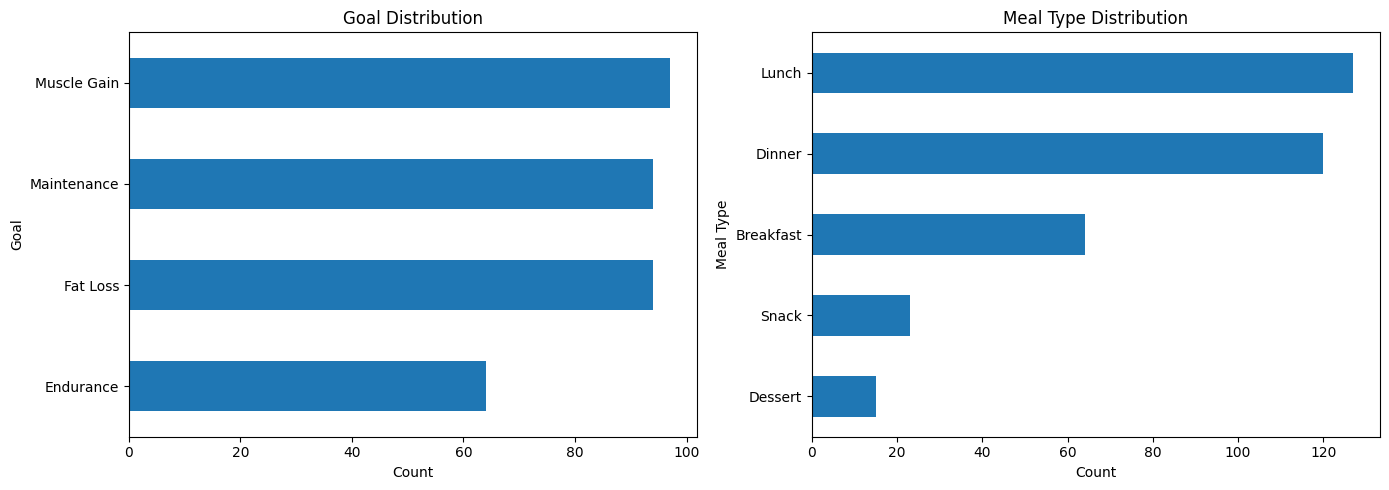

In [5]:

# Cell 4 — Quick EDA
print("Unique goals:", df["Goal"].unique())
print("Unique meal types:", df["Meal Type"].unique())
print("\nGoal counts:\n", df["Goal"].value_counts())
print("\nMeal type counts:\n", df["Meal Type"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Goal"].value_counts().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Goal Distribution")
axes[0].set_xlabel("Count")

df["Meal Type"].value_counts().sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Meal Type Distribution")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()


In [90]:
# Cell 5 — Build text fields for modeling
def normalize_text(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        x = " ".join([str(i) for i in x if i is not None])

    try:
        if pd.isna(x):
            return ""
    except:
        pass

    return re.sub(r"\s+", " ", str(x).strip().lower())


df["goal_l"] = df["Goal"].apply(normalize_text)
df["meal_type_l"] = df["Meal Type"].apply(normalize_text)
df["name_l"] = df["Name"].apply(normalize_text)
df["ingredients_l"] = df["Ingredients"].apply(normalize_text)
# df["cuisine_l"] = df["Cuisine"].apply(normalize_text)

df["meal_profile"] = (
    "name: "
    + df["Name"].astype(str)
    + " | goal: "
    + df["Goal"].astype(str)
    + " | meal type: "
    + df["Meal Type"].astype(str)
    +
    # " | cuisine: " + df["Cuisine"].astype(str) +
    " | ingredients: "
    + df["Ingredients"].astype(str)
)

# Normalized nutrition columns for ranking
for col in numeric_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    df[f"{col}_norm"] = (df[col] - col_min) / (col_max - col_min + 1e-9)

df[["meal_profile"] + numeric_cols].head()

,meal_profile,Calories,ProteinContent,CarbohydrateContent,FatContent
0,"name: Foul Medames with Olive Oil and Whole Wheat Bread | goal: Muscle Gain | meal type: Breakfast | ingredients: fava beans, olive oil, lemon, garlic, whole wheat bread",430,18,48,16
1,"name: Greek Yogurt with Dates and Walnuts | goal: Fat Loss | meal type: Breakfast | ingredients: greek yogurt, dates, walnuts",320,20,28,12
2,"name: Shakshuka with Whole Wheat Bread | goal: Maintenance | meal type: Breakfast | ingredients: eggs, tomatoes, peppers, onions, olive oil, whole wheat bread",410,22,30,18
3,"name: Labneh with Za'atar and Olive Oil | goal: Muscle Gain | meal type: Breakfast | ingredients: labneh, zaatar, olive oil, bread",390,17,24,22
4,"name: Oatmeal with Tahini and Banana | goal: Endurance | meal type: Breakfast | ingredients: oats, tahini, banana, milk",450,16,60,14



## 1) Intent Classifier

هنا بنولّد بيانات أسئلة صناعية من الداتا نفسها، ثم ندرب موديل يفهم نوع الطلب:
- اقتراح وجبة
- قائمة وجبات
- خطة يومية
- خطة أسبوعية
- قبل التمرين
- بعد التمرين
- تحليل وجبة
- مقارنة وجبتين
- بدائل وجبة


In [7]:
# Cell 6 — Synthetic intent dataset
id="fix1"
from sklearn.utils import resample

def balance_intents(df):
    max_count = df['intent'].value_counts().max()
    balanced = []

    for intent in df['intent'].unique():
        subset = df[df['intent'] == intent]

        if len(subset) < max_count:
            subset = resample(subset,
                             replace=True,
                             n_samples=max_count,
                             random_state=42)

        balanced.append(subset)

    return pd.concat(balanced)



id="fix2"
def downsample(df, max_per_class=200):
    parts = []
    for intent in df['intent'].unique():
        subset = df[df['intent'] == intent]
        subset = subset.sample(min(len(subset), max_per_class), random_state=42)
        parts.append(subset)
    return pd.concat(parts)


id="fix3"
def expand_templates(templates, times=20):
    new = []
    for _ in range(times):
        new.extend(templates)
    return new



GOAL_SYNONYMS = {
    "muscle gain": [
        "muscle gain",
        "gain muscle",
        "build muscle",
        "bulking",
        "increase muscle",
        "تضخيم",
        "بناء عضل",
        "زيادة العضلات",
    ],
    "fat loss": [
        "fat loss",
        "lose fat",
        "weight loss",
        "cutting",
        "lose weight",
        "تنشيف",
        "خسارة وزن",
        "رجيم",
        "حرق الدهون",
    ],
    "maintenance": [
        "maintenance",
        "maintain weight",
        "stay fit",
        "ثبات",
        "المحافظة على الوزن",
    ],
    "endurance": [
        "endurance",
        "stamina",
        "energy",
        "athletic endurance",
        "تحمل",
        "طاقة",
        "قدرة تحمل",
    ],
}

MEAL_SYNONYMS = {
    "breakfast": ["breakfast", "morning meal", "first meal", "فطور", "إفطار"],
    "lunch": ["lunch", "midday meal", "noon meal", "غداء"],
    "dinner": ["dinner", "evening meal", "night meal", "عشاء"],
    "snack": ["snack", "light meal", "between meals", "سناك", "وجبة خفيفة"],
    "dessert": ["dessert", "sweet", "after meal", "حلى", "تحلية"],
}

INTENT_LABELS = [
    "recommend_meal",
    "list_meals",
    "daily_plan",
    "weekly_plan",
    "pre_workout",
    "post_workout",
    "analyze_meal",
    "compare_meals",
    "substitute_meal",
]


def generate_goal_queries(goal):
    synonyms = GOAL_SYNONYMS.get(goal.lower(), [goal])
    meal_types = ["breakfast", "lunch", "dinner", "snack", "dessert"]
    queries = []
    for syn in synonyms:
        queries.extend(
            [
                f"recommend a meal for {syn}",
                f"give me a healthy meal for {syn}",
                f"I need food for {syn}",
                f"اقتراح وجبة لـ {syn}",
                f"اعطني وجبة مناسبة لـ {syn}",
            ]
        )
        for mt in meal_types:
            queries.extend(
                [
                    f"recommend a {mt} for {syn}",
                    f"give me a {mt} meal for {syn}",
                    f"show me {mt} options for {syn}",
                ]
            )
    return queries


def generate_mealtype_queries(meal_type):
    synonyms = MEAL_SYNONYMS.get(meal_type.lower(), [meal_type])
    queries = []
    for syn in synonyms:
        queries.extend(
            [
                f"list {syn} meals",
                f"show me {syn} options",
                f"I want a {syn}",
                f"اعطني وجبة {syn}",
                f"أريد {syn} صحي",
            ]
        )
    return queries


def build_intent_dataset(df):
    rows = []

    # Goal-based and meal-type-based recommendation/listing examples
    for _, row in df.iterrows():
        goal = row["Goal"].lower()
        meal_type = row["Meal Type"].lower()
        meal_name = row["Name"]

        # recommend_meal
        for q in generate_goal_queries(goal)[:8]:
            rows.append((q, "recommend_meal"))
        for q in generate_mealtype_queries(meal_type)[:6]:
            rows.append((q, "list_meals"))

        # meal-specific intents
        rows.extend(
            [
                (f"analyze {meal_name}", "analyze_meal"),
                (f"what are the calories and macros of {meal_name}", "analyze_meal"),
                (f"compare {meal_name} with another meal", "compare_meals"),
                (f"suggest a substitute for {meal_name}", "substitute_meal"),
            ]
        )

    # Generic plan / workout intents — multiple templates for each class
    generic_templates = {
        "daily_plan": [
            "create a daily meal plan for fat loss",
            "make me a one day meal plan for muscle gain",
            "daily nutrition plan for maintenance",
            "اعمل لي خطة يومية للتنشيف",
            "plan my meals for today for endurance",
            "give me a full day meal plan",
            "build a daily nutrition plan for me",
            "one day food plan for weight loss",
        ],
        "weekly_plan": [
            "create a weekly meal plan for fat loss",
            "make me a 7 day meal plan for muscle gain",
            "weekly nutrition plan for maintenance",
            "اعمل لي خطة أسبوعية للتضخيم",
            "plan my meals for the week for endurance",
            "give me a 7 day nutrition plan",
            "build a weekly food plan",
            "one week diet plan for fitness",
        ],
        "pre_workout": [
            "recommend a pre workout meal",
            "what should I eat before training",
            "وجبة قبل التمرين",
            "اقتراح سناك قبل التمرين",
            "best meal before gym",
            "what to eat before workout",
            "need energy before training",
            "suggest a light pre training meal",
        ],
        "post_workout": [
            "recommend a post workout meal",
            "what should I eat after training",
            "وجبة بعد التمرين",
            "اقتراح وجبة بعد التمرين",
            "best meal after gym",
            "what to eat after workout",
            "need recovery food after training",
            "suggest a high protein post training meal",
        ],
        "compare_meals": [
            "compare two meals for me",
            "which meal is better for fat loss",
            "قارن بين وجبتين",
            "أي وجبة أفضل للتضخيم",
            "compare meal A and meal B",
            "which option has better macros",
            "help me compare foods",
            "which is healthier between these meals",
        ],
        "analyze_meal": [
            "analyze this meal",
            "show me nutrition facts",
            "ما هي القيم الغذائية لهذه الوجبة",
            "احسب السعرات والماكروز",
            "what are the calories in this meal",
            "show protein carbs and fat",
            "nutrition breakdown for this food",
            "meal calorie analysis",
        ],
        "substitute_meal": [
            "suggest a healthy substitution",
            "replace this meal with a better option",
            "اعطني بديل صحي",
            "اقترح بديل لوجبة",
            "find a similar healthier meal",
            "recommend a substitute with similar taste",
            "give me an alternative food",
            "swap this meal with a lighter option",
        ],
        "recommend_meal": [
            "recommend a meal",
            "suggest me food",
            "اعطني وجبة مناسبة",
            "اقتراح وجبة صحية",
            "give me something to eat",
            "pick a meal for me",
            "show me a good meal option",
            "I want a meal suggestion",
        ],
        "list_meals": [
            "list meals",
            "show me meal options",
            "display all available meals",
            "اعطني قائمة الوجبات",
            "show me foods",
            "what meals do you have",
            "give me the available options",
            "list all healthy meals",
        ],
    }

    for intent, templates in generic_templates.items():
        expand_templates(templates, times=20)  # Expand each template to increase dataset size
        for q in templates:
            rows.append((q, intent))

    intent_df = pd.DataFrame(rows, columns=["text", "intent"])
    intent_df = (
        intent_df.drop_duplicates()
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    return intent_df


intent_df = build_intent_dataset(df)

intent_df = balance_intents(intent_df)

# intent_df = downsample(intent_df)



intent_texts = intent_df["text"].tolist()
intent_labels = intent_df["intent"].tolist()

intent_embeddings = embedder.encode(intent_texts, convert_to_tensor=False)


print("Intent dataset shape:", intent_df.shape)
display(intent_df.head(10))
print(intent_df["intent"].value_counts())

Intent dataset shape: (6354, 2)


,text,intent
0,analyze Kabsa with Fish,analyze_meal
3,what are the calories and macros of Flayfeleh (Bell peppers stuffed with rice and meat),analyze_meal
4,what are the calories and macros of Aish Baladi with Feta and Olives,analyze_meal
6,analyze Chicken and Vermicelli Soup,analyze_meal
7,ما هي القيم الغذائية لهذه الوجبة,analyze_meal
8,what are the calories and macros of Bamieh bzeit (Okra with olive oil and meat),analyze_meal
10,what are the calories and macros of Chicken Shawarma Stuffed Zucchini,analyze_meal
12,analyze Fattoush salad with grilled chicken,analyze_meal
15,analyze Jawziyeh (Walnut and date rolls),analyze_meal
16,analyze this meal,analyze_meal


intent
analyze_meal       706
compare_meals      706
substitute_meal    706
list_meals         706
recommend_meal     706
pre_workout        706
daily_plan         706
post_workout       706
weekly_plan        706
Name: count, dtype: int64


Intent Accuracy: 0.999213217938631

Classification report:

                 precision    recall  f1-score   support

   analyze_meal       1.00      1.00      1.00       141
  compare_meals       1.00      1.00      1.00       141
     daily_plan       1.00      1.00      1.00       141
     list_meals       1.00      1.00      1.00       142
   post_workout       1.00      1.00      1.00       141
    pre_workout       1.00      1.00      1.00       141
 recommend_meal       0.99      1.00      1.00       142
substitute_meal       1.00      0.99      1.00       141
    weekly_plan       1.00      1.00      1.00       141

       accuracy                           1.00      1271
      macro avg       1.00      1.00      1.00      1271
   weighted avg       1.00      1.00      1.00      1271



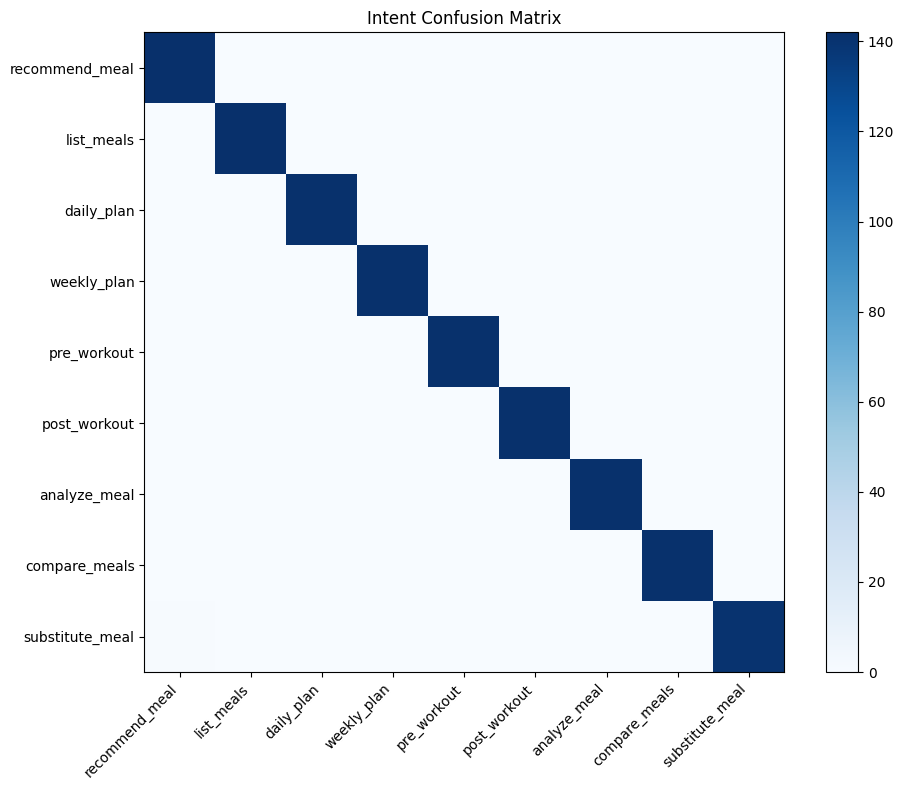

In [8]:

# Cell 7 — Train intent classifier
X_train, X_test, y_train, y_test = train_test_split(
    intent_df["text"],
    intent_df["intent"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=intent_df["intent"]
)

intent_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
])

intent_model.fit(X_train, y_train)
pred = intent_model.predict(X_test)

print("Intent Accuracy:", accuracy_score(y_test, pred))
print("\nClassification report:\n")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred, labels=INTENT_LABELS)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(INTENT_LABELS)))
ax.set_yticks(range(len(INTENT_LABELS)))
ax.set_xticklabels(INTENT_LABELS, rotation=45, ha="right")
ax.set_yticklabels(INTENT_LABELS)
ax.set_title("Intent Confusion Matrix")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()



## 2) Nutrition Prediction Model

هذا الموديل يتعلم العلاقة بين وصف الوجبة ومحتواها الغذائي:
- Calories
- Protein
- Carbs
- Fat

هذا الجزء مفيد جداً في العرض لأنه يثبت أن عندك موديل تنبؤ حقيقي وليس فقط قواعد.


In [9]:

# Cell 8 — Train nutrition regressor
nutrition_features = ["meal_profile"]
target_cols = ["Calories", "ProteinContent", "CarbohydrateContent", "FatContent"]

X = df["meal_profile"]
y = df[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

nutrition_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
nutrition_svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)

X_train_vec = nutrition_vectorizer.fit_transform(X_train)
X_test_vec = nutrition_vectorizer.transform(X_test)

X_train_red = nutrition_svd.fit_transform(X_train_vec)
X_test_red = nutrition_svd.transform(X_test_vec)

nutrition_model = MultiOutputRegressor(Ridge(alpha=1.0, random_state=RANDOM_STATE), n_jobs=1)
nutrition_model.fit(X_train_red, y_train)



y_pred = nutrition_model.predict(X_test_red)

for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"{col}: MAE={mae:.2f} | R2={r2:.3f}")

# Show a few predictions
pred_df = y_test.copy().reset_index(drop=True)
for i, col in enumerate(target_cols):
    pred_df[f"{col}_pred"] = np.round(y_pred[:, i], 1)

display(pred_df.head(10))


Calories: MAE=56.61 | R2=0.761
ProteinContent: MAE=5.55 | R2=0.593
CarbohydrateContent: MAE=8.72 | R2=0.704
FatContent: MAE=3.71 | R2=0.656


,Calories,ProteinContent,CarbohydrateContent,FatContent,Calories_pred,ProteinContent_pred,CarbohydrateContent_pred,FatContent_pred
0,510,46,10,28,343.7,27.9,14.5,14.5
1,460,22,42,20,472.1,25.6,39.4,20.7
2,280,6,44,10,362.7,11.3,49.5,12.7
3,850,58,42,48,701.0,42.0,45.4,35.0
4,610,32,74,14,580.8,32.6,65.0,15.2
5,140,12,1,9,405.8,24.3,24.0,22.7
6,310,6,18,24,455.2,20.7,38.9,20.9
7,460,26,38,18,487.7,27.1,35.9,23.2
8,350,12,28,20,444.8,19.5,47.1,18.3
9,310,32,12,12,359.8,26.8,20.8,14.7



## 3) Recommendation Engine

الترشيح هنا هجين:
- تشابه نصي مع طلب المستخدم
- مطابقة الهدف ونوع الوجبة
- درجة غذائية حسب الهدف
- دعم قبل/بعد التمرين


In [10]:
def predict_intent_semantic(user_input, threshold=0.55):
    emb = embedder.encode([user_input])
    sims = cosine_similarity(emb, intent_embeddings)[0]

    idx = np.argmax(sims)
    score = sims[idx]

    if score < threshold:
        return "unknown", score

    return intent_labels[idx], score

In [ ]:

# Cell 9 — Helpers for parsing user requests
GOAL_KEYWORDS = {
    "muscle gain": ["muscle gain", "gain muscle", "build muscle", "bulking", "تضخيم", "بناء عضل", "زيادة العضلات"],
    "fat loss": ["fat loss", "weight loss", "lose fat", "cutting", "تنشيف", "رجيم", "خسارة وزن", "حرق الدهون"],
    "maintenance": ["maintenance", "maintain weight", "stay fit", "ثبات", "المحافظة على الوزن"],
    "endurance": ["endurance", "stamina", "energy", "تحمل", "طاقة", "قدرة تحمل"],
}

MEAL_TYPE_KEYWORDS = {
    "breakfast": ["breakfast", "morning", "فطور", "إفطار"],
    "lunch": ["lunch", "noon", "midday", "غداء"],
    "dinner": ["dinner", "evening", "night", "عشاء"],
    "snack": ["snack", "light meal", "between meals", "سناك", "وجبة خفيفة"],
    "dessert": ["dessert", "sweet", "حلى", "تحلية"],
}

WORKOUT_KEYWORDS = {
    "pre_workout": ["pre workout", "before gym", "before training", "قبل التمرين", "قبل الرياضة"],
    "post_workout": ["post workout", "after gym", "after training", "بعد التمرين", "بعد الرياضة"],
}

def extract_goal(text):
    text_l = normalize_text(text)
    for goal, keys in GOAL_KEYWORDS.items():
        if any(k in text_l for k in keys):
            return goal
    return None

def extract_meal_type(text):
    text_l = normalize_text(text)
    for meal_type, keys in MEAL_TYPE_KEYWORDS.items():
        if any(k in text_l for k in keys):
            return meal_type
    return None

def extract_workout_intent(text):
    text_l = normalize_text(text)
    for wt, keys in WORKOUT_KEYWORDS.items():
        if any(k in text_l for k in keys):
            return wt
    return None

def find_meal_name_in_text(text, names=None):
    if names is None:
        names = df["Name"].tolist()
    text_l = normalize_text(text)

    # exact substring match
    exact_matches = [name for name in names if normalize_text(name) in text_l]
    if exact_matches:
        return exact_matches[0]

    # fuzzy match
    match = difflib.get_close_matches(text, names, n=1, cutoff=0.55)
    return match[0] if match else None


In [12]:

# Cell 10 — Recommendation scoring
goal_weights = {
    "fat loss": {"calories": -0.45, "protein": 0.40, "carbs": 0.05, "fat": -0.10},
    "muscle gain": {"calories": 0.25, "protein": 0.45, "carbs": 0.20, "fat": 0.05},
    "endurance": {"calories": 0.20, "protein": 0.20, "carbs": 0.45, "fat": -0.05},
    "maintenance": {"calories": 0.15, "protein": 0.25, "carbs": 0.25, "fat": 0.15},
}

workout_weights = {
    "pre_workout": {"calories": 0.10, "protein": 0.15, "carbs": 0.40, "fat": -0.15},
    "post_workout": {"calories": 0.15, "protein": 0.45, "carbs": 0.25, "fat": -0.10},
}

def nutrition_score(frame, goal=None, workout=None):
    cal = frame["Calories_norm"]
    pro = frame["ProteinContent_norm"]
    carb = frame["CarbohydrateContent_norm"]
    fat = frame["FatContent_norm"]

    if workout in workout_weights:
        w = workout_weights[workout]
    elif goal in goal_weights:
        w = goal_weights[goal]
    else:
        w = goal_weights["maintenance"]

    score = (
        w["calories"] * cal +
        w["protein"] * pro +
        w["carbs"] * carb +
        w["fat"] * fat
    )
    return score

profile_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
profile_matrix = profile_vectorizer.fit_transform(df["meal_profile"])

def recommend_meals(query, top_n=5, goal=None, meal_type=None, exclude_names=None):
    if exclude_names is None:
        exclude_names = set()
    else:
        exclude_names = set(exclude_names)

    q_vec = profile_vectorizer.transform([query])
    sim = cosine_similarity(q_vec, profile_matrix).ravel()

    frame = df.copy()
    frame["similarity"] = sim

    extracted_goal = goal or extract_goal(query)
    extracted_meal_type = meal_type or extract_meal_type(query)
    extracted_workout = extract_workout_intent(query)

    frame["nutrition_score"] = nutrition_score(frame, extracted_goal, extracted_workout)

    # Bonuses
    frame["bonus"] = 0.0
    if extracted_goal:
        frame.loc[frame["goal_l"] == extracted_goal, "bonus"] += 0.08
    if extracted_meal_type:
        frame.loc[frame["meal_type_l"] == extracted_meal_type, "bonus"] += 0.12
    if extracted_workout:
        frame["bonus"] += 0.05

    frame["final_score"] = 0.60 * frame["similarity"] + 0.30 * frame["nutrition_score"] + frame["bonus"]

    if exclude_names:
        frame = frame[~frame["Name"].isin(exclude_names)]

    # Filter by extracted goal / meal type if available
    if extracted_goal:
        filtered = frame[frame["goal_l"] == extracted_goal]
        if len(filtered) >= 3:
            frame = filtered
    if extracted_meal_type:
        filtered = frame[frame["meal_type_l"] == extracted_meal_type]
        if len(filtered) >= 3:
            frame = filtered

    result = frame.sort_values("final_score", ascending=False).head(top_n).copy()
    cols = ["Name", "Goal", "Meal Type", "Calories", "ProteinContent", "CarbohydrateContent", "FatContent", "final_score"]
    return result[cols].reset_index(drop=True)


In [93]:

# Cell 11 — Smart analysis, substitution, comparison
def find_meal_name_in_text(text, cutoff=0.55):
    text_n = normalize_text(text)
    meal_names = df["Name"].dropna().tolist()


    # 1) exact/partial substring match
    exact_matches = []
    for name in meal_names:
        name_n = normalize_text(name)
        if name_n in text_n:
            exact_matches.append(name)

    if len(exact_matches) == 1:
        return exact_matches[0]
    if len(exact_matches) > 1:
        # If multiple exact matches, pick the longest one (most specific)
        return exact_matches
    # 2) fuzzy match on full names
    fuzzy_matches = difflib.get_close_matches(text_n, meal_names, n=3, cutoff=cutoff)
    if fuzzy_matches:
        return fuzzy_matches[0] if len(fuzzy_matches) == 1 else fuzzy_matches
    

    # 3) token overlap fallback
    text_tokens = set(text_n.split())
    scored = []
    for name in meal_names:
        name_tokens = set(normalize_text(name).split())
        overlap = len(text_tokens & name_tokens)
        if overlap > 0:
            score = overlap / len(name_tokens)
            scored.append((score, name))

    if scored:
        scored.sort(reverse=True)
        best_score = scored[0][0]
        best = [name for score, name in scored if score == best_score]
        return best[0] if len(best) == 1 else best

    return None 

def get_meal_row(meal_name):
    match = df[df["Name"].str.lower() == normalize_text(meal_name)]
    if len(match) > 0:
        return match.iloc[0]
    # fallback fuzzy
    candidates = difflib.get_close_matches(meal_name, df["Name"].tolist(), n=1, cutoff=0.55)
    if candidates:
        return df[df["Name"] == candidates[0]].iloc[0]
    return None

def analyze_meal(meal_name, style="structured"):
    row = get_meal_row(meal_name)
    if row is None:
        return {"error": f"Meal not found: {meal_name}"}
    result = {
        "Name": row["Name"],
        "Goal": row["Goal"],
        "Meal Type": row["Meal Type"],
        # "Cuisine": row["Cuisine"],
        "Calories": int(row["Calories"]),
        "ProteinContent": int(row["ProteinContent"]),
        "CarbohydrateContent": int(row["CarbohydrateContent"]),
        "FatContent": int(row["FatContent"]),
        "Ingredients": row["Ingredients"],
    }

    if style == "colloquial":
        return format_analysis_colloquial(row)
    
    return result

def substitute_meal(meal_name, top_n=5, style="structured"):
    row = get_meal_row(meal_name)
    if row is None:
        error_df = pd.DataFrame([{"error": f"Meal not found: {meal_name}"}])
        return f"I couldn't find the meal '{meal_name}'. Please check the name and try again." if style == "colloquial" else error_df

    query = row["meal_profile"]
    q_vec = profile_vectorizer.transform([query])
    sim = cosine_similarity(q_vec, profile_matrix).ravel()

    frame = df.copy()
    frame["similarity"] = sim
    frame = frame[frame["Name"] != row["Name"]]
    frame["nutrition_score"] = nutrition_score(frame, goal=row["goal_l"])
    frame["final_score"] = 0.75 * frame["similarity"] + 0.25 * frame["nutrition_score"]

    # Prefer same goal and meal type if possible
    same_goal = frame[frame["goal_l"] == row["goal_l"]]
    if len(same_goal) >= 3:
        frame = same_goal

    same_type = frame[frame["meal_type_l"] == row["meal_type_l"]]
    if len(same_type) >= 3:
        frame = same_type

    cols = ["Name", "Goal", "Meal Type", "Calories", "ProteinContent", "CarbohydrateContent", "FatContent", "final_score"]
    result = frame.sort_values("final_score", ascending=False).head(top_n)[cols].reset_index(drop=True)

    if style == "colloquial":
        return format_substitutes_colloquial(meal_name, result)
    return result

    

def format_analysis_colloquial(row):
    return (
        f"Sure, the meal '{row['Name']}' is a {row['Meal Type']} suitable for {row['Goal']}.\n"
        f"It is suitable for the goal of {row['Goal']} because it has {row['Calories']} calories, "
        f"{row['ProteinContent']}g of protein, {row['CarbohydrateContent']}g of carbohydrates, and "
        f"{row['FatContent']}g of fat."
        f"In short: It is a good meal if you want a clear, balanced choice with basic ingredients: {row['Ingredients']}."
    )


def format_substitutes_colloquial(meal_name, substitutes_df):
    if substitutes_df is None or len(substitutes_df) == 0:
        return f"Sorry, I couldn't find any substitutes for '{meal_name}'."

    lines = [f"Here are some healthier substitutes for '{meal_name}':"]
    for i, (_, row) in enumerate(substitutes_df.iterrows(), start=1):
        lines.append(
            f"{i}) **{row['Name']}** — {row['Calories']} calories "
            f"protein: {row['ProteinContent']}g, carbohydrates: {row['CarbohydrateContent']}g, fat: {row['FatContent']}g. "
            f"[type: {row['Meal Type']}]"
        )

    lines.append("In short:These are good options if you want something similar but in a different order or a more relaxed approach.")


    return "\n".join(lines)


def compare_meals(meal_a, meal_b, goal=None):
    # print(f"Comparing '{meal_a}' vs '{meal_b}' for goal: {goal}")
    row_a = get_meal_row(meal_a)
    row_b = get_meal_row(meal_b)
    # print("Row A:", row_a["Name"] if row_a is not None else "Not found")
    # print("Row B:", row_b["Name"] if row_b is not None else "Not found")


    if row_a is None or row_b is None:
        return {"error": "One or both meals were not found."}

    goal = goal or "maintenance"

    df_pair = pd.DataFrame([row_a, row_b]).copy()
    df_pair["nutrition_score"] = nutrition_score(df_pair, goal=goal)

    winner_idx = df_pair["nutrition_score"].idxmax()
    winner = df_pair.loc[winner_idx, "Name"]

    return {
        "meal_a": row_a[["Name", "Calories", "ProteinContent", "CarbohydrateContent", "FatContent"]].to_dict(),
        "meal_b": row_b[["Name", "Calories", "ProteinContent", "CarbohydrateContent", "FatContent"]].to_dict(),
        "goal": goal,
        "winner_for_goal": winner
    }

def daily_plan(goal="maintenance"):
    meals = {}
    meals["breakfast"] = recommend_meals(f"breakfast for {goal}", top_n=1, goal=goal, meal_type="breakfast")
    meals["lunch"] = recommend_meals(f"lunch for {goal}", top_n=1, goal=goal, meal_type="lunch")
    meals["dinner"] = recommend_meals(f"dinner for {goal}", top_n=1, goal=goal, meal_type="dinner")
    meals["snack"] = recommend_meals(f"snack for {goal}", top_n=1, goal=goal, meal_type="snack")
    return meals

def weekly_plan(goal="maintenance"):
    days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    plan = []
    used = set()
    for day in days:
        b = recommend_meals(f"breakfast for {goal}", top_n=1, goal=goal, meal_type="breakfast", exclude_names=used)
        l = recommend_meals(f"lunch for {goal}", top_n=1, goal=goal, meal_type="lunch", exclude_names=used)
        d = recommend_meals(f"dinner for {goal}", top_n=1, goal=goal, meal_type="dinner", exclude_names=used)
        if len(b): used.add(b.iloc[0]["Name"])
        if len(l): used.add(l.iloc[0]["Name"])
        if len(d): used.add(d.iloc[0]["Name"])
        plan.append({
            "Day": day,
            "Breakfast": b.iloc[0]["Name"] if len(b) else None,
            "Lunch": l.iloc[0]["Name"] if len(l) else None,
            "Dinner": d.iloc[0]["Name"] if len(d) else None,
        })
    return pd.DataFrame(plan)



## 4) Reinforcement-Learning Style Feedback Layer

هذا جزء اختياري وخفيف.  
بدل ما ندرب RL حقيقي على بيانات صغيرة جدًا، نستخدم **online feedback**:
- المستخدم يعطي 👍 أو 👎
- النظام يحدث تفضيلاته تدريجيًا

هذا عملي أكثر للمشروع من RL كامل على 349 صف فقط.


In [14]:

# Cell 12 — Simple feedback policy (bandit-style online learning)
class FeedbackBandit:
    def __init__(self, epsilon=0.15):
        self.epsilon = epsilon
        self.counts = defaultdict(int)
        self.values = defaultdict(float)

    def choose(self, candidates):
        if not candidates:
            return None
        if random.random() < self.epsilon:
            return random.choice(candidates)
        return max(candidates, key=lambda x: self.values[x])

    def update(self, meal_name, reward):
        self.counts[meal_name] += 1
        n = self.counts[meal_name]
        old = self.values[meal_name]
        self.values[meal_name] = old + (reward - old) / n

bandit = FeedbackBandit(epsilon=0.15)

def recommend_with_feedback(query, top_n=5):
    recs = recommend_meals(query, top_n=top_n)
    if recs.empty:
        return recs
    chosen = bandit.choose(recs["Name"].tolist())
    return recs, chosen

# Example update:
# bandit.update("Chicken Salad", reward=1)   # user liked it
# bandit.update("Rice Pudding", reward=0)    # user disliked it


## 5) Memory (Session State)

In [106]:
# Cell 6 — Conversation memory

class ChatMemory:
    def __init__(self):
        self.last_goal = None
        self.last_meal_type = None
        self.last_meal_name = None
        self.last_compare_meals = None
        self.pending_intent = None
        self.pending_options = None

    def update(self, intent=None, goal=None, meal_type=None, meal_name=None,
               compare_meals=None, pending_intent=None, pending_options=None):
        if goal is not None:
            self.last_goal = goal
        if meal_type is not None:
            self.last_meal_type = meal_type
        if meal_name is not None:
            self.last_meal_name = meal_name
        if compare_meals is not None:
            self.last_compare_meals = compare_meals
        if pending_intent is not None:
            self.pending_intent = pending_intent
        if pending_options is not None:
            self.pending_options = pending_options


memory = ChatMemory()

## 6) Fallback (classification)

طلب توضيح من المستخدم عندما يكون النص المدخل غامض، هاد الشي ليخلي النموذج أكثر تفاعلاً


In [128]:
# Cell 7 — Fallback logic

# def ask_clarification(goal, meal_type):
#     if not goal:
#         return "Can you define your goal? (bulking, cutting, maintenance...)"
#     if not meal_type:
#         return "Do you want breakfast, lunch, or dinner?"
#     return "Can you clarify your request more?"

def ask_clarification(goal=None, meal_type=None):
    return {
        "intent": "clarification",
        "question": "Do you want breakfast, lunch, or dinner?",
        "goal": goal,
        "meal_type": meal_type
    }


## 5) Unified Chatbot Function

هذا هو المدخل النهائي للمشروع.  
تكتب رسالة المستخدم، والنظام:
1. يحدد intent
2. يستخرج الهدف/نوع الوجبة
3. يرجع الرد المناسب


In [129]:
# Cell 13 — Unified chatbot
def chatbot(user_text):

    # 1. Intent
    intent, score = predict_intent_semantic(user_text)
    # print(f"Predicted intent: {intent} (score: {score:.2f})")
    # intent = intent_model.predict([user_text])[0]

    # 2. 🤝 Greeting
    greeting_msg = None
    if is_greeting(text=user_text):
        if intent != "unknown":
            greeting_msg = handle_greeting(intent)["greeting"]
        else:
            return handle_greeting()

    # 3. Extract slots
    goal = extract_goal(user_text) or memory.last_goal
    meal_type = extract_meal_type(user_text) or memory.last_meal_type
    workout = extract_workout_intent(user_text)
    meal_name = find_meal_name_in_text(user_text) or memory.last_meal_name
   
   
    pending_intent = memory.pending_intent
    pending_options = memory.pending_options
    last_compare = memory.last_compare_meals

    # 🔥 HANDLE PENDING CLARIFICATION
    if pending_intent == "compare_meals" and pending_options:
        selected = find_meal_name_in_text(user_text)

        # إذا المستخدم اختار وجبة من الخيارات
        if isinstance(selected, str) and selected in pending_options:
            # إذا كان عندنا وجبة واحدة محفوظة سابقاً
            if last_compare and len(last_compare) == 1:
                meal_a = last_compare[0]
                meal_b = selected
            else:
                meal_a = pending_options[0]
                meal_b = selected

            # تنظيف الذاكرة
            memory.update(
                pending_intent=None,
                pending_options=None,
                compare_meals=[meal_a, meal_b]
            )

            result = compare_meals(meal_a, meal_b, goal=goal)

            return {
                "intent": "compare_meals",
                "comparison": result
            }
        

    
    # 4. Routing
    if intent == "recommend_meal":
        if not goal or not meal_type:
            return ask_clarification(goal=goal, meal_type=meal_type)

        top = recommend_meals(user_text, top_n=1, goal=goal, meal_type=meal_type)
        memory.update(intent, goal, meal_type)
        response = {
            "intent": intent,
            "goal": goal,
            "meal_type": meal_type,
            "results": top,
        }
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "list_meals":
        # list meals by inferred meal type or goal
        query = user_text
        top = recommend_meals(query, top_n=10, goal=goal, meal_type=meal_type)
        response = {
            "intent": intent,
            "goal": goal,
            "meal_type": meal_type,
            "results": top,
        }
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "pre_workout":
        top = recommend_meals(
            user_text,
            top_n=5,
            workout="pre_workout" if False else None,
            meal_type=meal_type,
        )
        # use nutrition scorer through query text
        response = {"intent": intent, "results": top}
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "post_workout":
        top = recommend_meals(user_text, top_n=5, meal_type=meal_type)
        response = {"intent": intent, "results": top}
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "daily_plan":
        g = goal or "maintenance"
        response = {"intent": intent, "goal": g, "plan": daily_plan(g)}
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "weekly_plan":
        g = goal or "maintenance"
        response = {"intent": intent, "goal": g, "plan": weekly_plan(g)}
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "analyze_meal":
        if meal_name is None:
            response = {"intent": intent, "error": "Please mention a meal name."}
            if greeting_msg:
                response["greeting"] = greeting_msg
            return response

        # row = df[df["Name"].str.lower() == meal_name].iloc[0]
        memory.update(intent, meal_name=meal_name)

        response = {
            "intent": intent,
            "analysis": analyze_meal(meal_name, style="colloquial"),
        }
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "substitute_meal":
        if meal_name is None:
            response = {"intent": intent, "error": "Please mention a meal name."}
            if greeting_msg:
                response["greeting"] = greeting_msg
            return response

        if isinstance(meal_name, list):
            response = {
                "intent": intent,
                "error": "I found multiple matching meals. Please specify one.",
                "candidates": meal_name[:5],
            }
            if greeting_msg:
                response["greeting"] = greeting_msg
            return response

        response = {
            "intent": intent,
            "substitutes": substitute_meal(meal_name, top_n=5, style="colloquial"),
        }
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    if intent == "compare_meals":
        names = []

        for m in df["Name"].tolist():
            if normalize_text(m) in normalize_text(user_text):
                if m not in names:
                    names.append(m)
        # fallback split
        parts = re.split(r"\band\b", user_text, flags=re.IGNORECASE)
        for p in parts:
            m = find_meal_name_in_text(p)
            if m and m not in names:
                names.append(m)

        if len(names) < 2:
            response = {
                "intent": intent,
                "error": "Please mention 2 meal names clearly.",
            }
            if greeting_msg:
                response["greeting"] = greeting_msg
            return response
        

        
        # 🔴 clarification step
        if isinstance(names[0], list) or isinstance(names[1], list):
            
            options = []
            matched_compare_meals = [] = []

            if isinstance(names[0], list):
                options.extend(names[0][:5])
            if isinstance(names[1], list):
                options.extend(names[1][:5])

            if isinstance(names[0], str):
                matched_compare_meals.append(names[0])
            if isinstance(names[1], str):
                matched_compare_meals.append(names[1])

            response = {
                "intent": "clarification",
                "message": "I couldn't clearly identify two meals.",
                "question": "Which meals do you want to compare?",
                "options": options,
            }

            memory.update(
                intent="compare_meals",
                compare_meals=matched_compare_meals,
                pending_intent="compare_meals",
                pending_options=options
            )

            if greeting_msg:
                response["greeting"] = greeting_msg

            return response

        result = compare_meals(names[0], names[1], goal=goal)
        memory.update(
            intent="compare_meals",
            compare_meals=[names[0], names[1]],
            meal_name=names[1]
        )

        if "error" in result:
            return {"intent": intent, "message": result["error"]}

        return {"intent": intent, "comparison": result}

    if intent == "unknown":
        response = {
            "intent": "unknown",
            "message": "I didn't quite understand you 😅 Could you rephrase it?",
        }
        if greeting_msg:
            response["greeting"] = greeting_msg
        return response

    # return "OK 👍"


# Try examples
examples = [
    "Hi there!",
    "Hi, Recommend a meal for muscle gain",
    "Give me a breakfast for fat loss",
    "Create a weekly meal plan for endurance",
    "Analyze Chicken Salad",
    "Suggest a substitute for Chicken Fattah with Garlic Vinegar",
    "Compare Chicken Salad and Beef Stew for fat loss",
    "Compare Chicken Tawook Salad Bowl and Beef Stew for fat loss",
    "Okra Stew with Lean Beef"
]
for ex in examples:
    out = chatbot(ex)
    print("output:", out)
    print("\nUSER:", ex)
    # print("greeting:", out.get("message", ""))
    print("INTENT:", out["intent"])


    if "greeting" in out:
        print(out["greeting"])

    if "question" in out:
        print(out["question"])
        print("Options:", out.get("options", []))

    if "results" in out:
        display(out["results"].head(3))
    elif "plan" in out:
        display(out["plan"].head(7))
    elif "analysis" in out:
        print(out["analysis"])
    elif "substitutes" in out:
        display(out["substitutes"])
    print("-" * 50)

output: {'intent': 'greeting', 'greeting': '👋 How can I help you? You can request a meal, meal analysis, or a diet plan.'}

USER: Hi there!
INTENT: greeting
👋 How can I help you? You can request a meal, meal analysis, or a diet plan.
--------------------------------------------------
output: {'intent': 'clarification', 'question': 'Do you want breakfast, lunch, or dinner?', 'goal': 'muscle gain', 'meal_type': None}

USER: Hi, Recommend a meal for muscle gain
INTENT: clarification
Do you want breakfast, lunch, or dinner?
Options: []
--------------------------------------------------
output: {'intent': 'recommend_meal', 'goal': 'fat loss', 'meal_type': 'breakfast', 'results':                                  Name      Goal  Meal Type  Calories  \
0  Yogurt with Cucumber and Flaxseeds  Fat Loss  Breakfast       250   

   ProteinContent  CarbohydrateContent  FatContent  final_score  
0              18                   10          12     0.321421  }

USER: Give me a breakfast for fat loss

,Name,Goal,Meal Type,Calories,ProteinContent,CarbohydrateContent,FatContent,final_score
0,Yogurt with Cucumber and Flaxseeds,Fat Loss,Breakfast,250,18,10,12,0.321421


--------------------------------------------------
output: {'intent': 'weekly_plan', 'goal': 'endurance', 'plan':          Day                       Breakfast  \
0     Monday       Asida with Honey and Ghee   
1    Tuesday      Freekeh Porridge with Nuts   
2  Wednesday    Semolina Porridge with Dates   
3   Thursday  Banana Date Smoothie with Oats   
4     Friday     Tahini Banana Smoothie Bowl   
5   Saturday  Oatmeal with Tahini and Banana   
6     Sunday     Date and Peanut Butter Oats   

                                     Lunch  \
0             Chicken Biryani Arabic Style   
1                 Ruz Bukhari (Uzbek Rice)   
2             Freekeh with Grilled Chicken   
3             Beef Rice Pilaf Arabic Style   
4               Chicken Fatteh with Yogurt   
5  Bulgur Pilaf with Chickpeas and Chicken   
6   Freekeh Pilaf with Chicken and Almonds   

                                     Dinner  
0                Fish Sayadiya with Freekeh  
1             Chicken Couscous with Rais

,Day,Breakfast,Lunch,Dinner
0,Monday,Asida with Honey and Ghee,Chicken Biryani Arabic Style,Fish Sayadiya with Freekeh
1,Tuesday,Freekeh Porridge with Nuts,Ruz Bukhari (Uzbek Rice),Chicken Couscous with Raisins
2,Wednesday,Semolina Porridge with Dates,Freekeh with Grilled Chicken,Chicken and Bulgur Bowl
3,Thursday,Banana Date Smoothie with Oats,Beef Rice Pilaf Arabic Style,Chickpea and Potato Curry
4,Friday,Tahini Banana Smoothie Bowl,Chicken Fatteh with Yogurt,Semolina Cake with Date Syrup
5,Saturday,Oatmeal with Tahini and Banana,Bulgur Pilaf with Chickpeas and Chicken,Chicken and Rice Soup
6,Sunday,Date and Peanut Butter Oats,Freekeh Pilaf with Chicken and Almonds,Chicken Rice Bowl with Yogurt Mint Sauce


--------------------------------------------------
output: {'intent': 'analyze_meal', 'analysis': "Sure, the meal 'Tuna and Chickpea Salad' is a Dinner suitable for Fat Loss.\nIt is suitable for the goal of Fat Loss because it has 370 calories, 34g of protein, 20g of carbohydrates, and 16g of fat.In short: It is a good meal if you want a clear, balanced choice with basic ingredients: tuna, chickpeas, parsley, lemon, olive oil."}

USER: Analyze Chicken Salad
INTENT: analyze_meal
Sure, the meal 'Tuna and Chickpea Salad' is a Dinner suitable for Fat Loss.
It is suitable for the goal of Fat Loss because it has 370 calories, 34g of protein, 20g of carbohydrates, and 16g of fat.In short: It is a good meal if you want a clear, balanced choice with basic ingredients: tuna, chickpeas, parsley, lemon, olive oil.
--------------------------------------------------
output: {'intent': 'substitute_meal', 'substitutes': "Here are some healthier substitutes for 'Chicken Fattah with Garlic Vinegar':\n1)

"Here are some healthier substitutes for 'Chicken Fattah with Garlic Vinegar':\n1) **Shish Tawook with Rice and Garlic Sauce** — 700 calories protein: 48g, carbohydrates: 64g, fat: 24g. [type: Lunch]\n2) **Chicken Mandi** — 750 calories protein: 45g, carbohydrates: 82g, fat: 22g. [type: Lunch]\n3) **Chicken Kabsa** — 720 calories protein: 45g, carbohydrates: 78g, fat: 24g. [type: Lunch]\n4) **Chicken Molokhia with Brown Rice** — 670 calories protein: 46g, carbohydrates: 56g, fat: 28g. [type: Lunch]\n5) **Chicken and Potato Kabob Plate** — 760 calories protein: 46g, carbohydrates: 58g, fat: 30g. [type: Lunch]\nIn short:These are good options if you want something similar but in a different order or a more relaxed approach."

--------------------------------------------------
output: {'intent': 'clarification', 'message': "I couldn't clearly identify two meals.", 'question': 'Which meals do you want to compare?', 'options': ['Chicken Tawook Salad Bowl', 'Chicken Mandi', 'Chicken Kabsa', 'Okra Stew with Lean Beef', 'Beef Tongue Stew with Rice']}

USER: Compare Chicken Salad and Beef Stew for fat loss
INTENT: clarification
Which meals do you want to compare?
Options: ['Chicken Tawook Salad Bowl', 'Chicken Mandi', 'Chicken Kabsa', 'Okra Stew with Lean Beef', 'Beef Tongue Stew with Rice']
--------------------------------------------------
output: {'intent': 'compare_meals', 'comparison': {'meal_a': {'Name': 'Chicken Tawook Salad Bowl', 'Calories': 470, 'ProteinContent': 44, 'CarbohydrateContent': 16, 'FatContent': 22}, 'meal_b': {'Name': 'Chicken Tawook Salad Bowl', 'Calories': 470, 'ProteinContent': 44, 'CarbohydrateContent': 16, 'FatContent': 22}, 'goal': 'fat loss', 'winner_for_goal': 235    Chicken Tawook S


## 6) Save Models

احفظ الموديلات حتى تستخدمها لاحقًا في API أو واجهة.


In [112]:
text = ["2 boiled eggs"]

# 1. vectorize
vec = nutrition_vectorizer.transform(text)

# 2. reduce
red = nutrition_svd.transform(vec)

# 3. predict
model1 = nutrition_model.predict(red)[0]

print(model1)

[409.81333731  24.10080362  27.05124238  20.0665628 ]


In [113]:

# Cell 14 — Save artifacts
joblib.dump(intent_model, os.path.join(MODEL_DIR, "intent_model.joblib"))
joblib.dump(nutrition_model, os.path.join(MODEL_DIR, "nutrition_model.joblib"))
joblib.dump(nutrition_vectorizer, os.path.join(MODEL_DIR, "nutrition_vectorizer.joblib"))
joblib.dump(nutrition_svd, os.path.join(MODEL_DIR, "nutrition_svd.joblib"))
joblib.dump(profile_vectorizer, os.path.join(MODEL_DIR, "profile_vectorizer.joblib"))
joblib.dump(df, os.path.join(MODEL_DIR, "meals_dataframe.joblib"))
joblib.dump(bandit, os.path.join(MODEL_DIR, "bandit_state.joblib"))

print("Saved all artifacts in:", MODEL_DIR)


Saved all artifacts in: models



## 7) Demo

- سؤال للموديل
- ترشيحات
- تحليل وجبة
- خطة أسبوعية


In [114]:

# Cell 15 — Demo interactions
print(chatbot("I want a meal for fat loss and breakfast"))
print(chatbot("Create a daily meal plan for muscle gain"))
print(chatbot("Analyze the meal Chicken Salad"))


{'intent': 'recommend_meal', 'goal': 'fat loss', 'meal_type': 'breakfast', 'results':                                  Name      Goal  Meal Type  Calories  \
0  Yogurt with Cucumber and Flaxseeds  Fat Loss  Breakfast       250   

   ProteinContent  CarbohydrateContent  FatContent  final_score  
0              18                   10          12     0.332847  }
{'intent': 'daily_plan', 'goal': 'muscle gain', 'plan': {'breakfast':                               Name         Goal  Meal Type  Calories  \
0  Chicken and Egg Breakfast Plate  Muscle Gain  Breakfast       500   

   ProteinContent  CarbohydrateContent  FatContent  final_score  
0              35                   22          26     0.518742  , 'lunch':            Name         Goal Meal Type  Calories  ProteinContent  \
0  Duck Maqluba  Muscle Gain     Lunch       840              50   

   CarbohydrateContent  FatContent  final_score  
0                   72          38     0.564698  , 'dinner':                                

In [126]:
# Cell 10 — Testing
memory.__init__()  # reset memory
print( memory.__dict__ )

print(chatbot("مرحبا"))
# print( memory.__dict__ )
print(chatbot("Recommend a meal for cutting"))
# print( memory.__dict__ )
print(chatbot("breakfast"))
# print( memory.__dict__ )
print(chatbot("analyze chicken rice"))
# print( memory.__dict__ )

{'last_goal': None, 'last_meal_type': None, 'last_meal_name': None, 'last_compare_meals': None, 'pending_intent': None, 'pending_options': None}
{'intent': 'greeting', 'greeting': '👋 How can I help you? You can request a meal, meal analysis, or a diet plan.'}
Do you want breakfast, lunch, or dinner?
{'intent': 'list_meals', 'goal': None, 'meal_type': 'breakfast', 'results':                                      Name         Goal  Meal Type  Calories  \
0         Chicken and Egg Breakfast Plate  Muscle Gain  Breakfast       500   
1         Chicken Shawarma Breakfast Wrap  Muscle Gain  Breakfast       510   
2               Asida with Honey and Ghee    Endurance  Breakfast       560   
3              Freekeh Porridge with Nuts    Endurance  Breakfast       480   
4       Grilled Halloumi and Egg Sandwich  Muscle Gain  Breakfast       520   
5  Scrambled Eggs with Potatoes and Bread  Muscle Gain  Breakfast       520   
6          Chicken Liver and Egg Scramble  Muscle Gain  Breakfast     